In [13]:
#TODO 1: Initialize data
import pandas as pd 

data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Shape: (768, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0

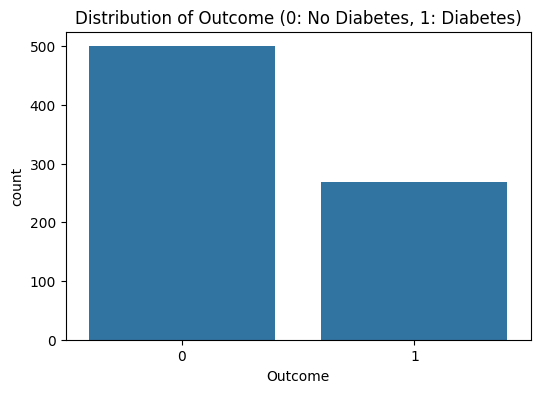

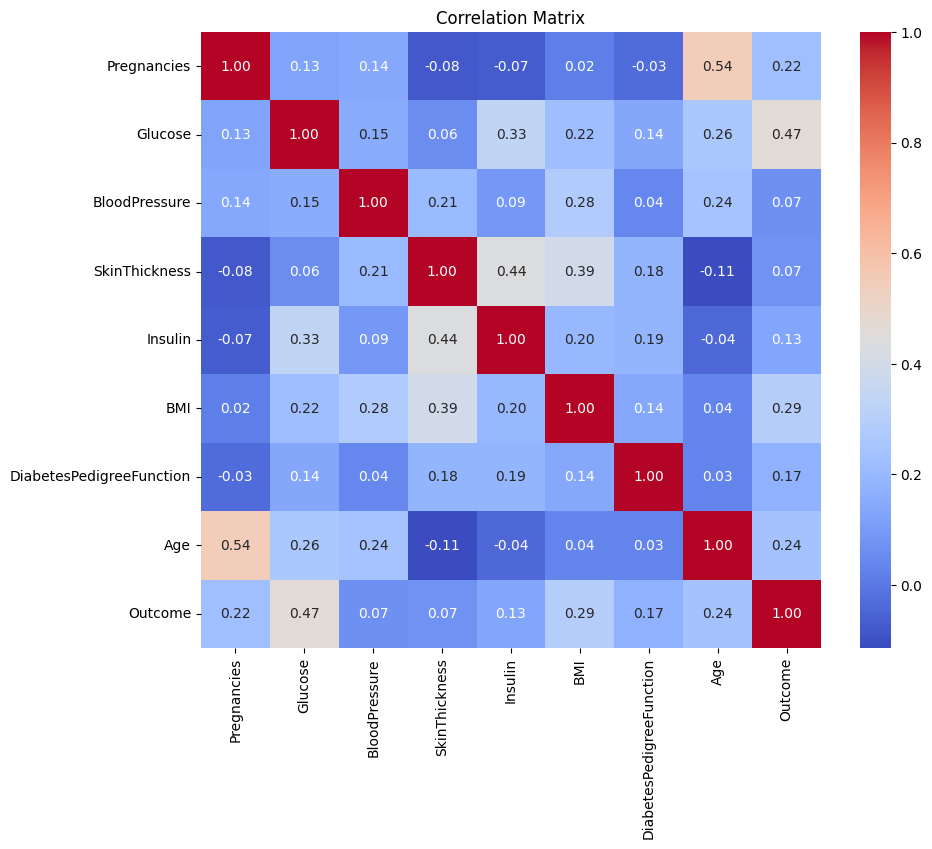

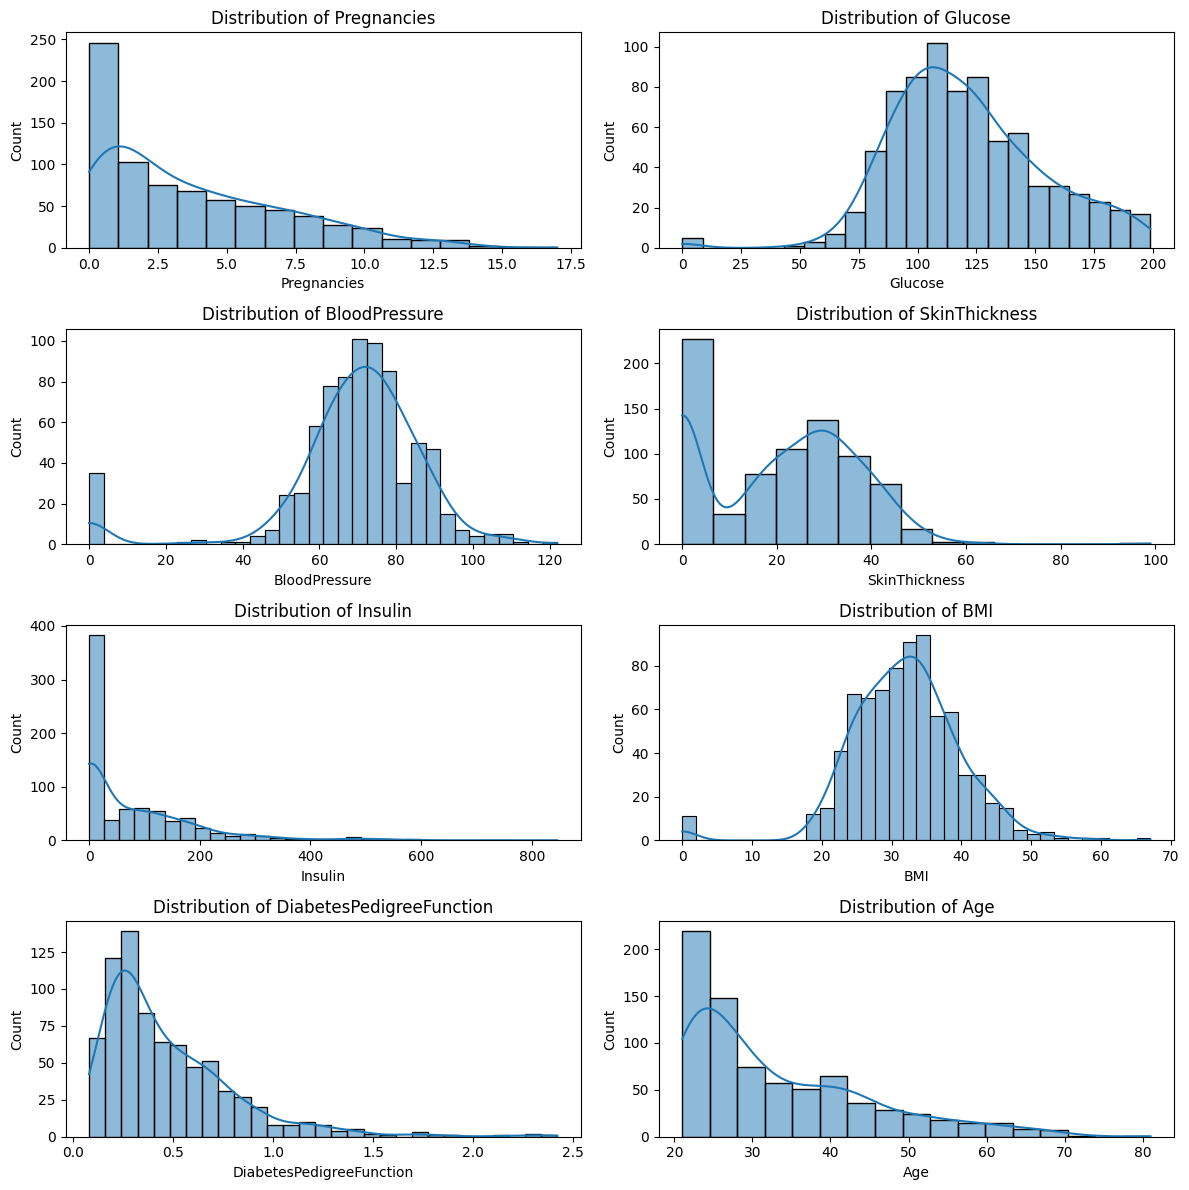

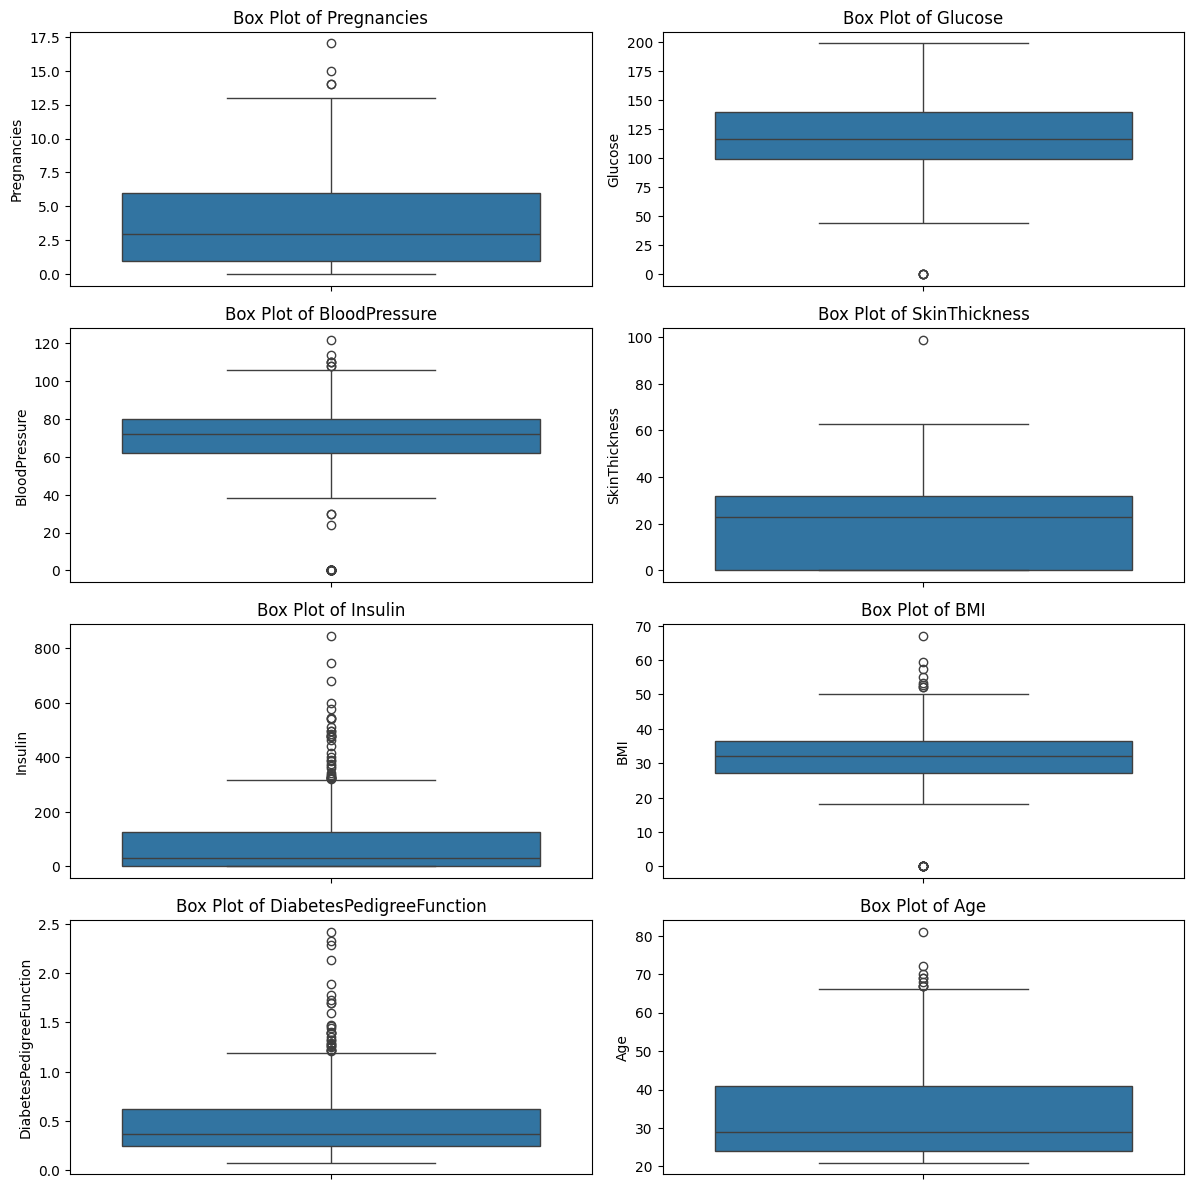

In [14]:
#TODO 5: Create a more modular EDA
import matplotlib.pyplot as plt
import seaborn as sns

def perform_eda(df):
    print("Dataset Shape:", df.shape)
    print("\nDataset Info:")
    print(df.info())
    
    # Check for missing values
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    # Check for duplicates
    print("\nDuplicates:")
    print(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)
    
    # Basic statistics
    print("\nBasic Statistics:")
    print(df.describe())
    
    # Distribution of target variable
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Outcome', data=df)
    plt.title('Distribution of Outcome (0: No Diabetes, 1: Diabetes)')
    plt.show()
    
    # Correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()
    
    # Distribution of numerical variables
    numerical_cols = df.columns[:-1]  # Exclude Outcome
    fig, axes = plt.subplots(4, 2, figsize=(12, 12))
    axes = axes.ravel()
    for idx, col in enumerate(numerical_cols):
        sns.histplot(df[col], ax=axes[idx], kde=True)
        axes[idx].set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
    
    # Box plots for outliers
    fig, axes = plt.subplots(4, 2, figsize=(12, 12))
    axes = axes.ravel()
    for idx, col in enumerate(numerical_cols):
        sns.boxplot(y=df[col], ax=axes[idx])
        axes[idx].set_title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()

perform_eda(data)

In [15]:
#TODO: Handle zero values/NaN
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data[col] = data[col].replace(0, data[col][data[col] != 0].median())

In [16]:
#TODO: Prepare data for modeling
from sklearn.model_selection import train_test_split, GridSearchCV

X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
#TODO Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Decision Tree with gini criterion:
Accuracy: 0.6818
ROC AUC: 0.6357
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



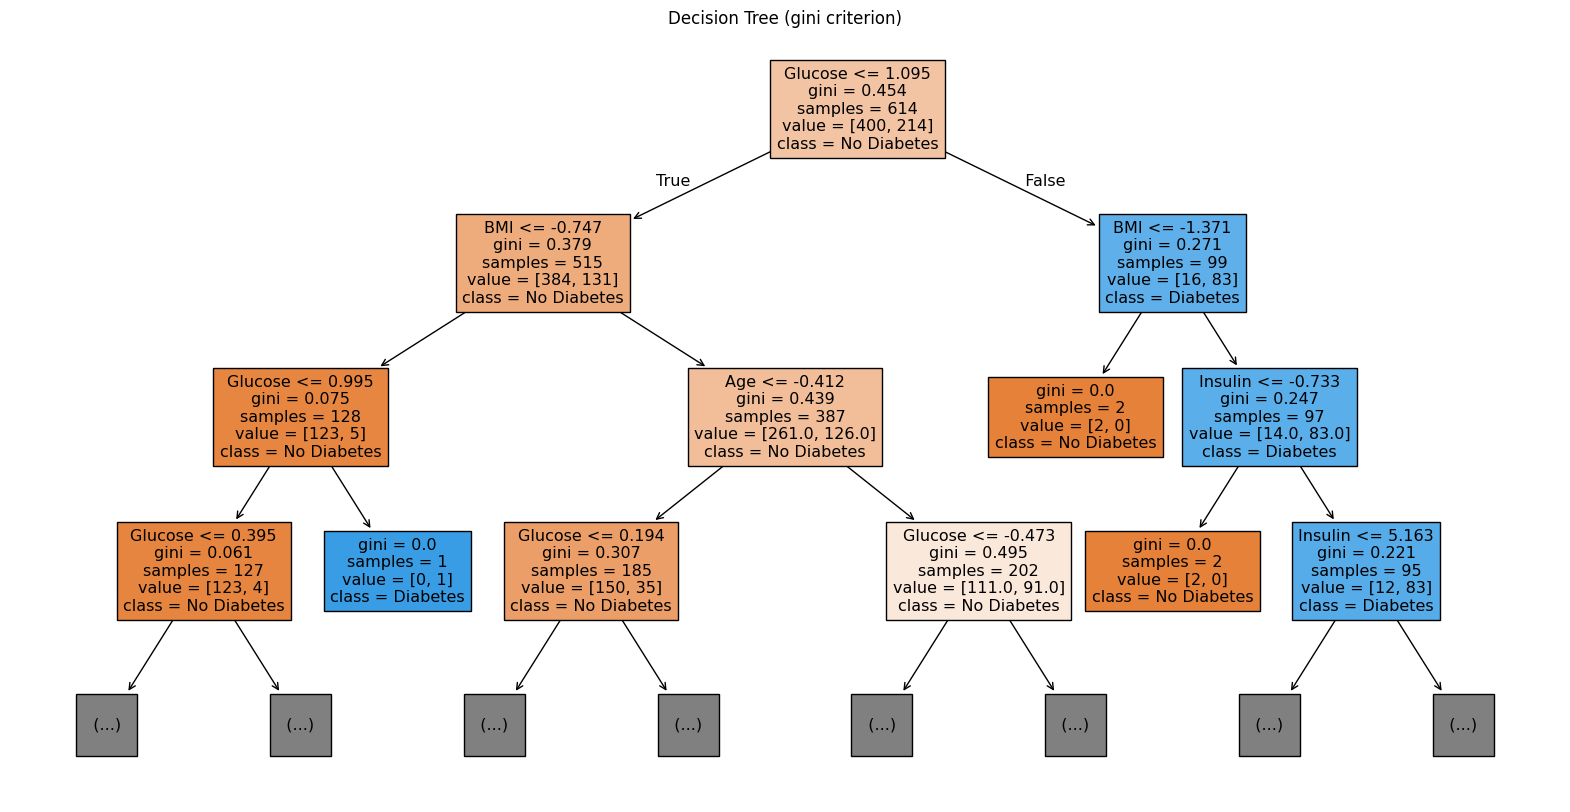


Decision Tree with entropy criterion:
Accuracy: 0.6753
ROC AUC: 0.6393
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154



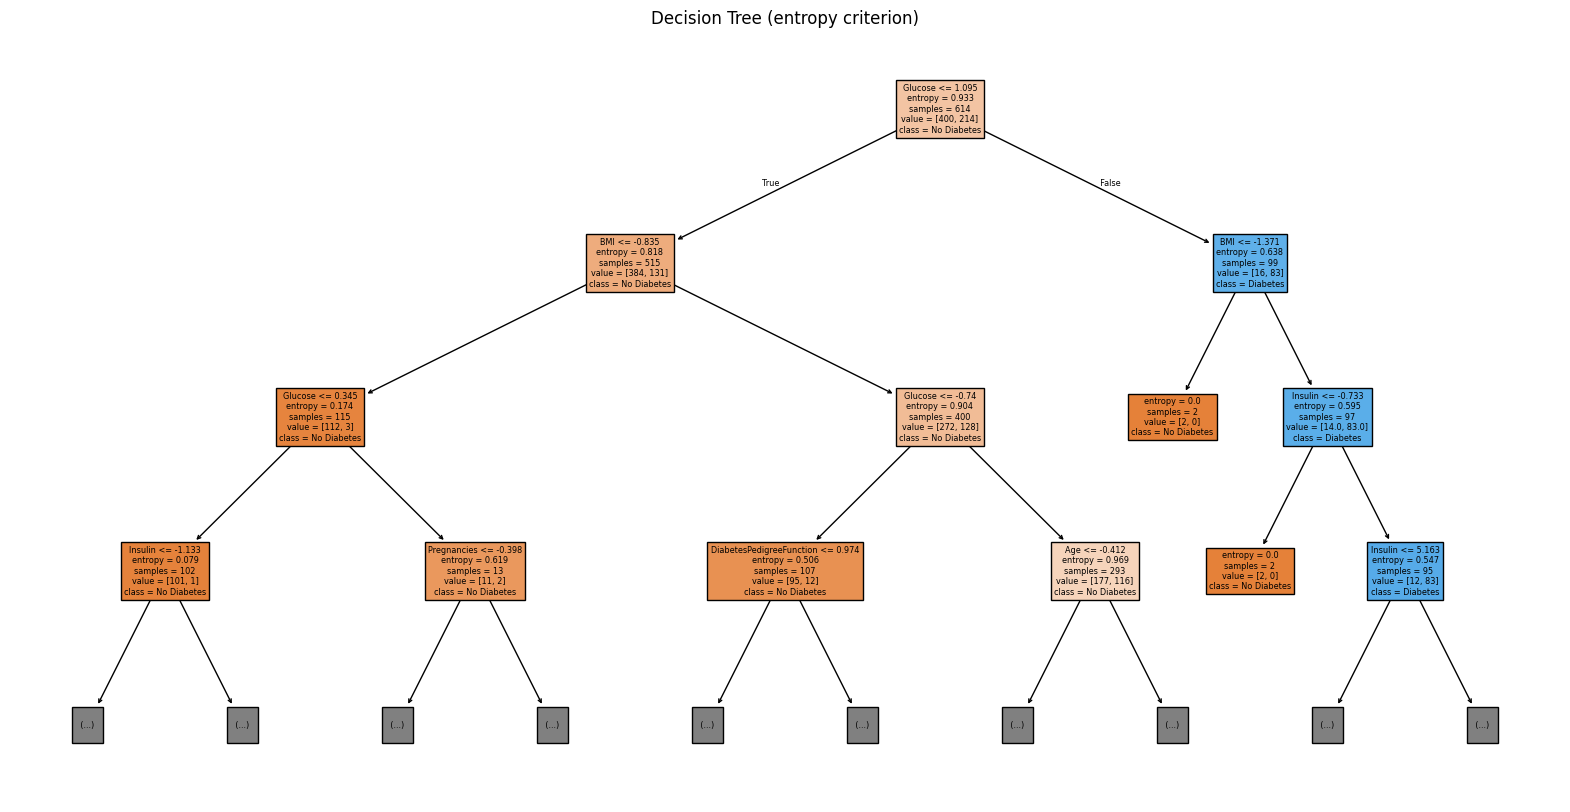

<Figure size 800x500 with 0 Axes>

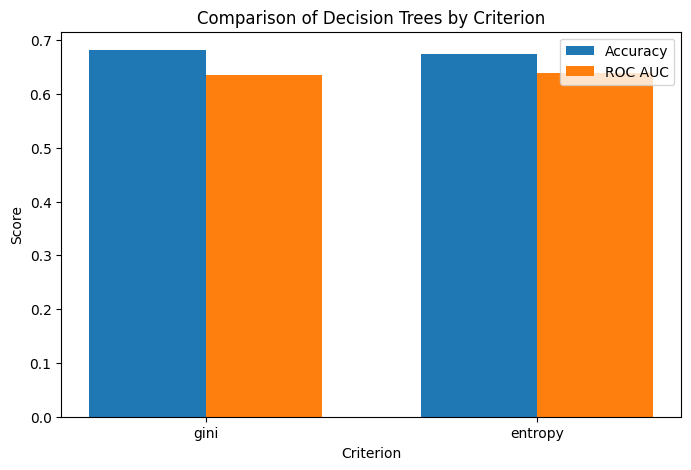


Best criterion based on ROC AUC: entropy

Optimized Decision Tree:
Best Parameters: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Accuracy: 0.6948
ROC AUC: 0.5989
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



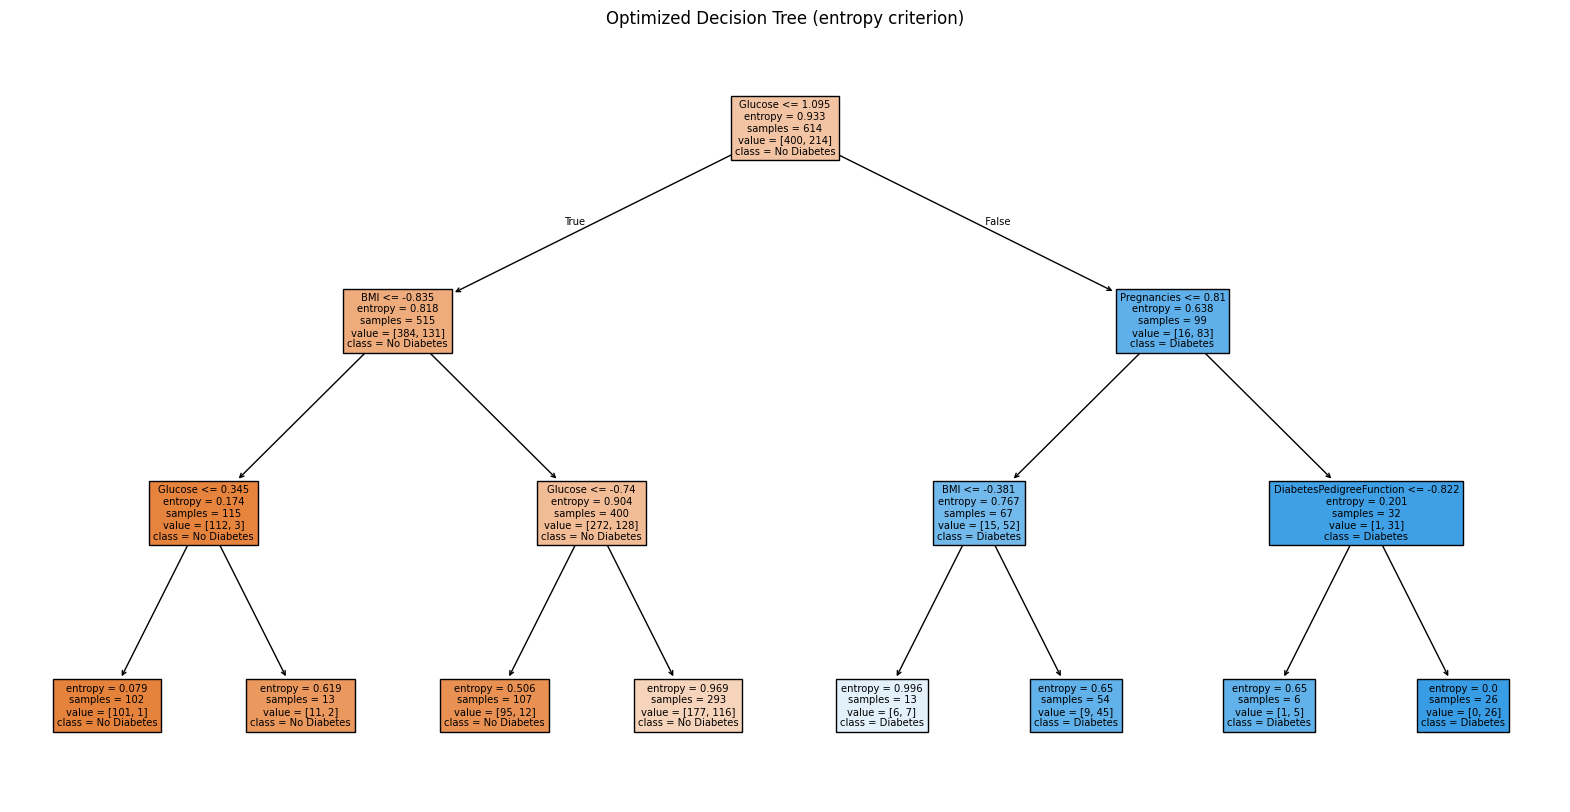


Model Comparison:
gini Decision Tree - Accuracy: 0.6818, ROC AUC: 0.6357
entropy Decision Tree - Accuracy: 0.6753, ROC AUC: 0.6393
Optimized entropy Decision Tree - Accuracy: 0.6948, ROC AUC: 0.5989

Model and scaler saved as 'diabetes_decision_tree_model.pkl' and 'scaler.pkl'


In [19]:
#TODO: Build decision trees with different purity functions
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib
from sklearn.tree import plot_tree
import numpy as np

purity_functions = ['gini', 'entropy']
results = {}

for criterion in purity_functions:
    # Train decision tree
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Predict and evaluate
    y_pred = dt.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    results[criterion] = {
        'model': dt,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'classification_report': classification_report(y_test, y_pred)
    }
    
    print(f"\nDecision Tree with {criterion} criterion:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(results[criterion]['classification_report'])
    
    # Visualize the tree
    plt.figure(figsize=(20, 10))
    plot_tree(dt, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, max_depth=3)
    plt.title(f'Decision Tree ({criterion} criterion)')
    plt.show()

# Compare purity functions
plt.figure(figsize=(8, 5))
criteria = list(results.keys())
accuracies = [results[c]['accuracy'] for c in criteria]
roc_aucs = [results[c]['roc_auc'] for c in criteria]

x = np.arange(len(criteria))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy')
ax.bar(x + width/2, roc_aucs, width, label='ROC AUC')
ax.set_xlabel('Criterion')
ax.set_ylabel('Score')
ax.set_title('Comparison of Decision Trees by Criterion')
ax.set_xticks(x)
ax.set_xticklabels(criteria)
ax.legend()
plt.show()

# Step 4: Optimize the best model
# Select the best criterion based on ROC AUC
best_criterion = max(results, key=lambda x: results[x]['roc_auc'])
print(f"\nBest criterion based on ROC AUC: {best_criterion}")

# Grid search for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

dt_opt = DecisionTreeClassifier(criterion=best_criterion, random_state=42)
grid_search = GridSearchCV(dt_opt, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model
best_dt = grid_search.best_estimator_
y_pred_opt = best_dt.predict(X_test_scaled)
opt_accuracy = accuracy_score(y_test, y_pred_opt)
opt_roc_auc = roc_auc_score(y_test, y_pred_opt)

print("\nOptimized Decision Tree:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy: {opt_accuracy:.4f}")
print(f"ROC AUC: {opt_roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_opt))

# Visualize optimized tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, max_depth=3)
plt.title(f'Optimized Decision Tree ({best_criterion} criterion)')
plt.show()

# Model comparison
print("\nModel Comparison:")
for criterion in purity_functions:
    print(f"{criterion} Decision Tree - Accuracy: {results[criterion]['accuracy']:.4f}, ROC AUC: {results[criterion]['roc_auc']:.4f}")
print(f"Optimized {best_criterion} Decision Tree - Accuracy: {opt_accuracy:.4f}, ROC AUC: {opt_roc_auc:.4f}")

# Step 5: Save the model
joblib.dump(best_dt, 'diabetes_decision_tree_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel and scaler saved as 'diabetes_decision_tree_model.pkl' and 'scaler.pkl'")